# Flight Arrival Delay Prediction
## ECS 171 Group 21 Project - Aseel Lakadia

Delayed flights are one of the most common inconveniences during air travel that cause frustration and schedule-related issues. The purpose of our research project is to develop an approach that will allow us to predict whether a certain flight will be delayed or not by analyzing different aspects of air traffic operations, such as the airline used for traveling, the airport departure point and arrival point, scheduled departure and arrival times, flight route, and flight distance. Our approach aims at identifying possible causes of delay and helping people plan their trips better by gaining more insight into factors that cause flight delays.

## We will sepreate this model into 2 parts:

## 1) Classification:
To classify if a flight had a significant delay (> 45 mins)  in arrival time

### Models Used
* SVM
* MLP Neural Network
* Random Forest

## 2) Regression:
To predict the actual arrival delay duration in minutes for already-delayed flights


### Models Used
* Linera Regression  
* Decision Tree Regressor
* Random Forest Regressor

---
# 1) Importing Necessary Libraries:

In [119]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, f1_score, recall_score, precision_score
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import validation_curve
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor




In [120]:
!pip install -q joblib

In [121]:
from pickle import TRUE
TRAIN_MODELS = False
SAVE_MODELS = False

ARTIFACT_PATH = "flight_delay_artifacts.joblib"

import os
import joblib

---
# 2) Importing Dataset & EDA

## For this Model we would be using the follwing Dataset:

* Kaggle: [Flight_delay.csv](https://www.kaggle.com/datasets/undersc0re/flight-delay-and-causes?resource=download)

* contains approx. 500,000 flight records
* 28 features

Each row represents one flight record, and columns represent features such as airline, origin, destination, flight distance, scheduled time, departure delay, and arrival delay


In [122]:
df = pd.read_csv('Flight_delay.csv')
df.head()

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,3,10,0,N,0,2,0,0,0,32
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,3,7,0,N,0,10,0,0,0,47
2,4,03-01-2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,6,8,0,N,0,8,0,0,0,72
3,4,03-01-2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,7,8,0,N,0,3,0,0,0,12
4,4,03-01-2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,4,9,0,N,0,0,0,0,0,16


---
# 2.1) Checking the Correlation matrix for the Numerical Features

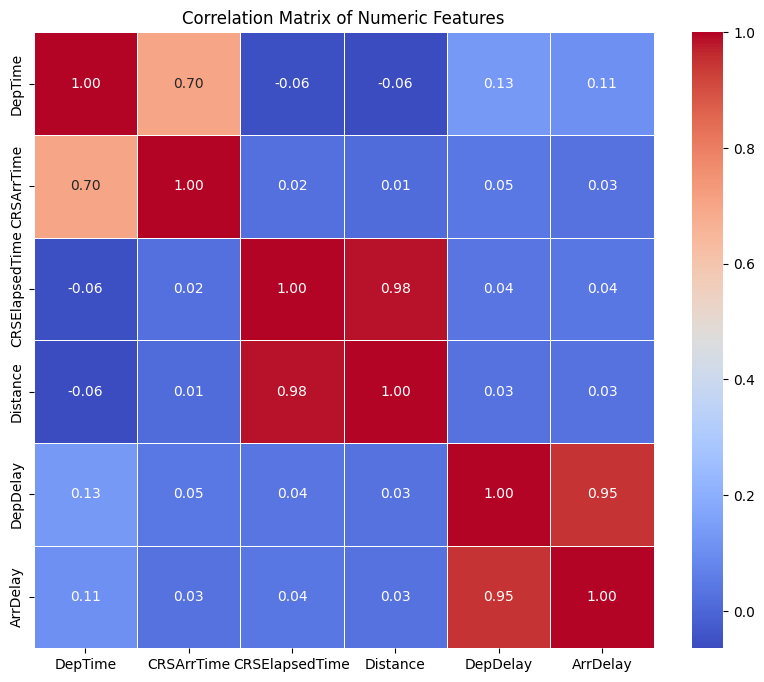

In [123]:


plt.figure(figsize=(10, 8))
corr_matrix = df[['DepTime', 'CRSArrTime', 'CRSElapsedTime', 'Distance', 'DepDelay', 'ArrDelay']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

## Analysis
We dropped the `DepDelay` column due to its extremely high correlation with the `ArrDelay` column. The other columns were retained because they do not directly provide information about the arrival delay but can provide insights into the data nonetheless. Even though there are columns whose correlations with the `ArrDelay` column are very low, the same cannot be said about the categorical variables as they might have higher associations with delays. These include columns such as the weekday, airline, originating airport, and the destination airport. This is due to the possibility of certain days being more crowded than others.

---
# 2.2) Analysing and Creating the Target Variable: `ArrDelay` & `is_delayed_45+`

<Axes: xlabel='ArrDelay', ylabel='Count'>

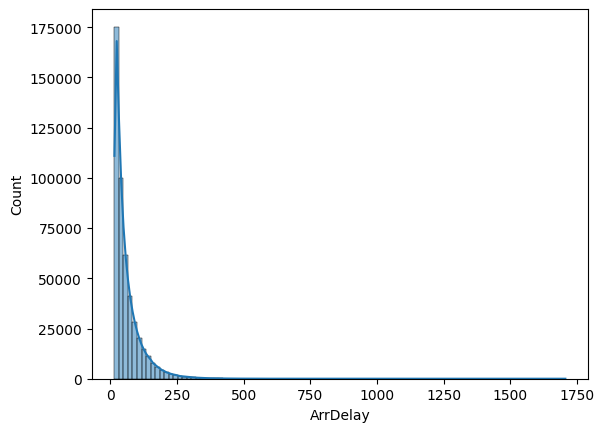

In [124]:
sns.histplot(df['ArrDelay'], bins=100, kde=True)

In [125]:
avg_carrier_delay = df['ArrDelay'].mean()
print(f"Average Arrival Delay: {avg_carrier_delay:.2f} minutes")

median_arrival_delay = df['ArrDelay'].median()
print(f"Median Arrival Delay: {median_arrival_delay:.2f} minutes")

Average Arrival Delay: 60.91 minutes
Median Arrival Delay: 42.00 minutes


In [126]:
df['is_delayed_45+'] = np.where(df['ArrDelay'] > 45, 1, 0)

delay_percentage = df['is_delayed_45+'].mean() * 100
print(f"Percentage of flights delayed by 45 minutes or more: {delay_percentage:.2f}%")

Percentage of flights delayed by 45 minutes or more: 46.10%


## Analysis:

The `ArrDelay` variable exhibits a strong **right-skewness**, with most of the values being low on delays while there are a few outliers with extremely high delays. This illustrates the existence of very high delays in the data, which are however relatively few when compared to normal delays.

A value of **45 minutes** was used to differentiate between **a significant delay vs a not significant delay**. Where **ArrDelay < 45** is considered to be a less significant delay while **ArrDelay >= 45** is considered a significant delay. We picked the 45 minutes cut-off point due to the fact that it is long enough to impact passenger connections, but still produces an equal proportion in the two categories.

---
# 2.3) Relation of Categorical Features with target

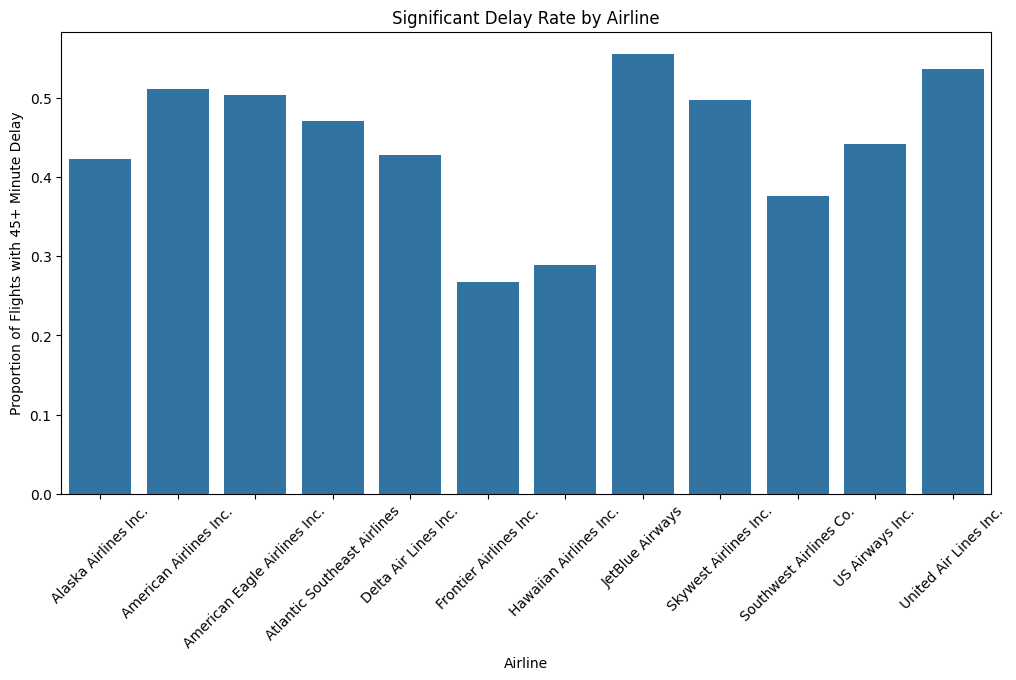

In [127]:
plt.figure(figsize=(12, 6))

airline_delay_rate = (
    df.groupby('Airline')['is_delayed_45+']
    .mean()

)

sns.barplot(
    x=airline_delay_rate.index,
    y=airline_delay_rate.values
)

plt.title('Significant Delay Rate by Airline')
plt.xlabel('Airline')
plt.ylabel('Proportion of Flights with 45+ Minute Delay')
plt.xticks(rotation=45)
plt.show()

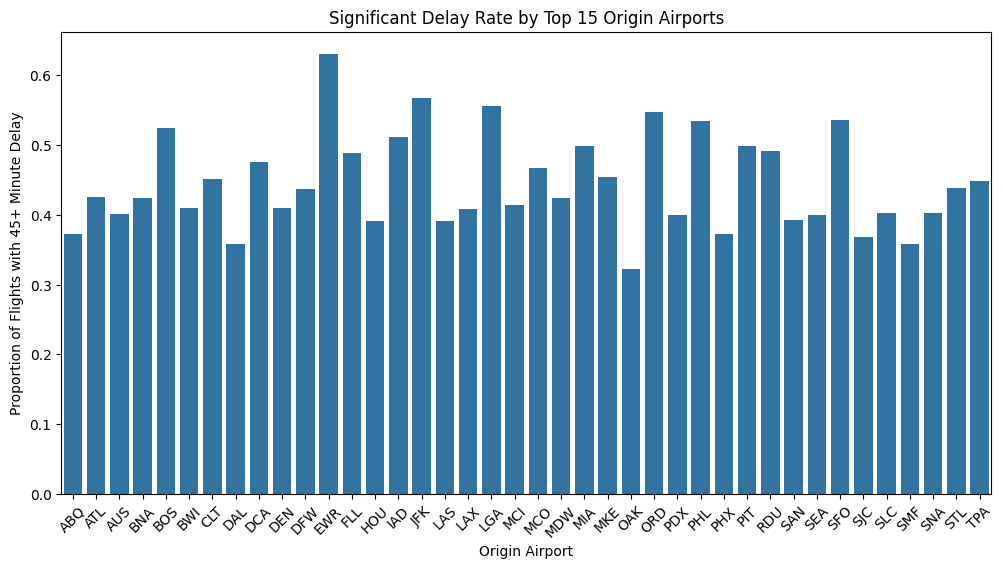

In [128]:
plt.figure(figsize=(12, 6))

top_origins = df['Origin'].value_counts().head(40).index

origin_delay_rate = (
    df[df['Origin'].isin(top_origins)]
    .groupby('Origin')['is_delayed_45+']
    .mean()

)

sns.barplot(
    x=origin_delay_rate.index,
    y=origin_delay_rate.values
)

plt.title('Significant Delay Rate by Top 15 Origin Airports')
plt.xlabel('Origin Airport')
plt.ylabel('Proportion of Flights with 45+ Minute Delay')
plt.xticks(rotation=45)
plt.show()

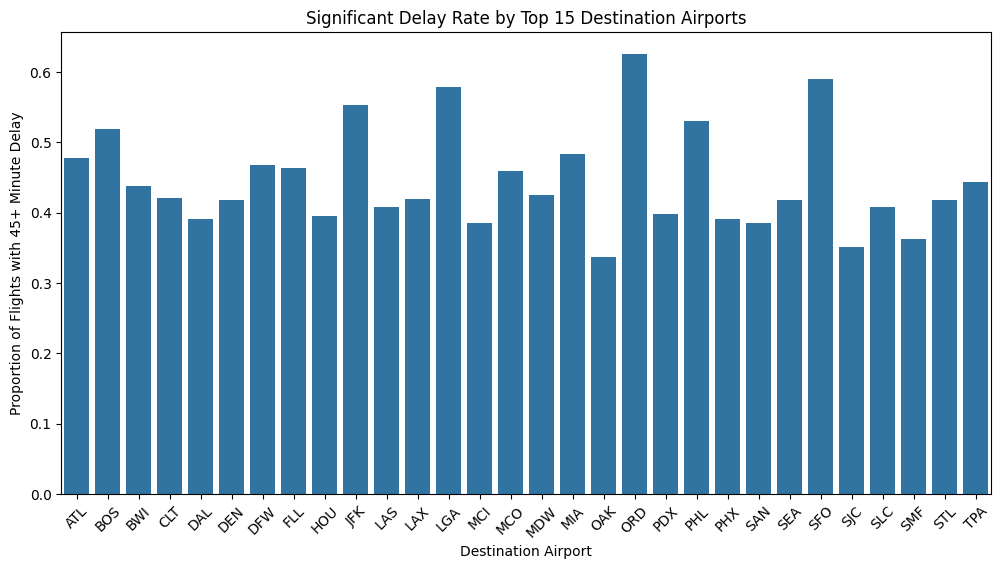

In [129]:
plt.figure(figsize=(12, 6))

top_dests = df['Dest'].value_counts().head(30).index

dest_delay_rate = (
    df[df['Dest'].isin(top_dests)]
    .groupby('Dest')['is_delayed_45+']
    .mean()

)

sns.barplot(
    x=dest_delay_rate.index,
    y=dest_delay_rate.values
)

plt.title('Significant Delay Rate by Top 15 Destination Airports')
plt.xlabel('Destination Airport')
plt.ylabel('Proportion of Flights with 45+ Minute Delay')
plt.xticks(rotation=45)
plt.show()

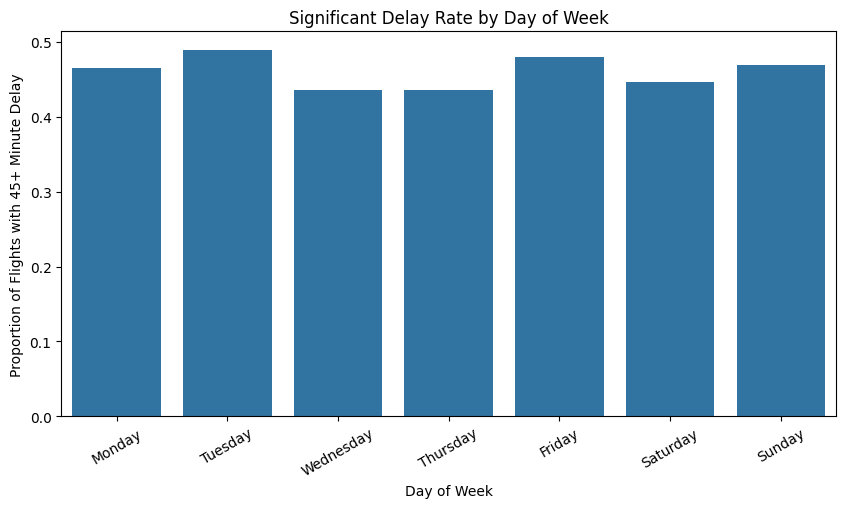

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

day_names = {
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday'
}

day_delay_rate = (
    df.groupby('DayOfWeek')['is_delayed_45+']
    .mean()
    .reset_index()
)

day_delay_rate['DayName'] = day_delay_rate['DayOfWeek'].map(day_names)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=day_delay_rate,
    x='DayName',
    y='is_delayed_45+',
    order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

plt.title('Significant Delay Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Proportion of Flights with 45+ Minute Delay')
plt.xticks(rotation=30)
plt.show()

## Analysis:
Categorical features are good for visualization since there is significant variation in the significant delays among different airlines, originating airports, and destination airports. For instance, some airlines such as **JetBlue** and **United** experience many 45+ minute delay rates, whereas airlines such as **Hawaiian** and **Frontier** record lower significant delays. Similarly, there is an observable pattern among different airports where originating airports such as **JFK**, **LGA**, **ORD**, **SFO**, and **PHL** report high significant delays, along with destination airports such as **ORD**, **SFO**, **LGA**, **JFK**, and **PHL**.

There is not much variation in the **day-of-week** graph, which suggests that day-of-week does not have much predictive power on its own. However, it might help in identifying significant delays when used together with airline, airport, routes, and timing features. Models such as **MLP** and **Random Forest** will leverage combined features to predict significant delays.

---
## 2.4) Slecting the Columns to use

We selected this dataframe because it includes flight information that can help predict the severity of an already-delayed flight.

- **DayOfWeek**: Helps capture weekly travel patterns because delays may differ between weekdays and weekends.
- **Date**: Helps capture seasonal or busy travel-period patterns.
- **Airline**: Different airlines may have different delay patterns.
- **Origin**: The departure airport can affect delays because some airports are busier than others.
- **Dest**: The destination airport can also affect arrival delay severity.
- **DepTime**: Flights at different times of the day may have different delay patterns.
- **CRSArrTime**: Scheduled arrival time helps capture time-of-day arrival patterns.
- **CRSElapsedTime**: Scheduled flight duration helps describe the type of flight route.
- **Distance**: Flight distance helps show whether the flight is short or long.
- **ArrDelay**: Used to create the target variable `Delay45Plus` and as the regression target, but it is not used as an input feature.

We chose these features because they are useful for understanding airline, airport, route, time, and departure-delay patterns while avoiding data leakage from post-flight columns like `CarrierDelay`, `WeatherDelay`, `ArrTime`, `AirTime`, and `ActualElapsedTime`.

In [131]:
df = df[['DayOfWeek', 'Date', 'Airline', 'Origin', 'DepTime', 'Dest', 'CRSArrTime', 'CRSElapsedTime','Distance', 'ArrDelay', 'is_delayed_45+' ]]
df

,DayOfWeek,Date,Airline,Origin,DepTime,Dest,CRSArrTime,CRSElapsedTime,Distance,ArrDelay,is_delayed_45+
0,4,03-01-2019,Southwest Airlines Co.,IND,1829,BWI,1925,90,515,34,0
1,4,03-01-2019,Southwest Airlines Co.,IND,1937,LAS,1940,250,1591,57,1
2,4,03-01-2019,Southwest Airlines Co.,IND,1644,MCO,1725,135,828,80,1
3,4,03-01-2019,Southwest Airlines Co.,IND,1452,PHX,1625,240,1489,15,0
4,4,03-01-2019,Southwest Airlines Co.,IND,1323,TPA,1510,135,838,16,0
...,...,...,...,...,...,...,...,...,...,...,...
484546,5,13-06-2019,American Airlines Inc.,DFW,1609,MCO,1915,160,984,27,0
484547,6,14-06-2019,American Airlines Inc.,DFW,1616,MCO,1915,160,984,39,0
484548,2,17-06-2019,American Airlines Inc.,DFW,1617,MCO,1915,160,984,47,1
484549,7,22-06-2019,American Airlines Inc.,DFW,1607,MCO,1915,160,984,26,0


---
# 3) Pre-processing the Dataset

---
# 3.1) Accounting for the Null Values

In [132]:
df.isnull().sum()

,0
DayOfWeek,0
Date,0
Airline,0
Origin,0
DepTime,0
Dest,0
CRSArrTime,0
CRSElapsedTime,0
Distance,0
ArrDelay,0


We have no Null values so no need to remove anything

---
# 3.2) Feature Engineering: Adjusting the Date & Time Columns

We are transforming our raw features such as `Date`, `DepTime`, and `CRSArrTime` to more useful time-dependent features.

Instead of providing the entire date/time value in `hhmm` format, we derive features such as **month, day, departure hour, departure minute, scheduled arrival hour, and scheduled arrival minute** from these dates/times. These features help the model to learn about seasonal, monthly, and daily variations of flights.

In [133]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day

df['DepHour'] = df['DepTime'] // 100
df['DepMinute'] = df['DepTime'] % 100

df['CRSArrHour'] = df['CRSArrTime'] // 100
df['CRSArrMinute'] = df['CRSArrTime'] % 100

### Dropping The Original Date column

In [134]:
df = df.drop(columns=['Date'])
df = df.drop(columns=['DepTime'])
df = df.drop(columns=['CRSArrTime'])

---
# 3.4) Isolating Categorical Variables & Encoding

We are applying **one hot encoding** on our categorical features to create numeric columns. This is important as the airline, origin airport, and destination airport features are defined by text strings which are not compatible with machine learning models. By one hot encoding, we can create different columns with 0 or 1 values representing different categories, which will enable our algorithm to learn whether a particular airline or airport is associated with delay severity.

In [135]:
ctgry = df.select_dtypes(include='object').columns
ctgry

Index(['Airline', 'Origin', 'Dest'], dtype='object')

### Using One-Hot Encoding for all the categorical Data Identified above

In [136]:
df_encoded = pd.get_dummies(df,  drop_first=True)
df_encoded

,DayOfWeek,CRSElapsedTime,Distance,ArrDelay,is_delayed_45+,month,day,DepHour,DepMinute,CRSArrHour,...,Dest_TYR,Dest_TYS,Dest_VLD,Dest_VPS,Dest_WRG,Dest_WYS,Dest_XNA,Dest_YAK,Dest_YKM,Dest_YUM
0,4,90,515,34,0,1,3,18,29,19,...,False,False,False,False,False,False,False,False,False,False
1,4,250,1591,57,1,1,3,19,37,19,...,False,False,False,False,False,False,False,False,False,False
2,4,135,828,80,1,1,3,16,44,17,...,False,False,False,False,False,False,False,False,False,False
3,4,240,1489,15,0,1,3,14,52,16,...,False,False,False,False,False,False,False,False,False,False
4,4,135,838,16,0,1,3,13,23,15,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484546,5,160,984,27,0,6,13,16,9,19,...,False,False,False,False,False,False,False,False,False,False
484547,6,160,984,39,0,6,14,16,16,19,...,False,False,False,False,False,False,False,False,False,False
484548,2,160,984,47,1,6,17,16,17,19,...,False,False,False,False,False,False,False,False,False,False
484549,7,160,984,26,0,6,22,16,7,19,...,False,False,False,False,False,False,False,False,False,False


---
# 3.5) Initializing Feature and target as seperate variables

In [137]:
X_class = df_encoded.drop(columns=['ArrDelay', 'is_delayed_45+'])
X_reg = df_encoded.drop(columns=['ArrDelay', 'is_delayed_45+'])
y_classification = df_encoded['is_delayed_45+']
y_regression = df_encoded['ArrDelay']


print(f"Classification features shape: {X_class.shape}")
print(f"Regression features shape: {X_reg.shape}")
print(f"Classification target shape: {y_classification.shape}")
print(f"Regression target shape: {y_regression.shape}")

Classification features shape: (484551, 566)
Regression features shape: (484551, 566)
Classification target shape: (484551,)
Regression target shape: (484551,)


---
# 3.6) Creating the Test Train Split

After preprocessing, both the classification and regression datasets contained 484,551 flight records and 570 input features. The large number of features comes from one-hot encoding categorical variables such as airline, origin airport, and destination airport. The classification target `Delay45Plus` has one label for each flight, and the regression target `ArrDelay` has one arrival delay value for each flight. Since the feature and target shapes match correctly, the dataset is ready for train-test splitting and model training.

In [138]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_regression,
    test_size=0.2,
    random_state=42
)

---
# 3.7) Scaling:


The scaling is done to accommodate models such as SVM and MLP because these models tend to be affected by the magnitude of the numeric input value. For instance, some of the features such as the distance or time have higher values compared to the other categorical features. Scaling ensures that we do not give too much weight to some features simply because their numeric values are higher compared to others. SVM and MLP require scaling while RF does not.

In [139]:
if not TRAIN_MODELS:
    artifacts = joblib.load(ARTIFACT_PATH)



    best_rf_model = artifacts["best_rf_model"]
    best_dt_model = artifacts["best_dt_model"]
    best_rf_reg_model = artifacts["best_rf_reg_model"]
    mlp_default = artifacts["mlp_default"]
    best_rf_params = artifacts["best_rf_params"]
    best_dt_params = artifacts["best_dt_params"]
    best_rf_reg_params = artifacts["best_rf_reg_params"]

    print("Saved models loaded successfully.")

Saved models loaded successfully.


In [140]:
scaler = StandardScaler()

X_train_class_scaled = scaler.fit_transform(X_train_class)
X_test_class_scaled = scaler.transform(X_test_class)

print("Training shape:", X_train_class_scaled.shape)
print("Testing shape:", X_test_class_scaled.shape)

Training shape: (387640, 566)
Testing shape: (96911, 566)


---
# 4) Classification Task:

For classification problem, we have to predict whether flight’s arrival delay will be **significant** or **not significant**. Here, for convenience, we call this variable “delayed” and “not delayed”. But in the context of our project, we should say whether delay will be serious enough to influence passenger’s schedule, connection and other things.

We use **ArrDelay** to construct the classifier labels. The threshold is **45 minutes**:

* **Class 0**: `ArrDelay < 45`
  That means flight’s arrival is delayed but the delay is not really significant.

* **Class 1**: `ArrDelay >= 45`
  That means the arrival delay is significant and could influence travel plans of passengers.

Why we used the threshold value **45 minutes**? The answer is that it has practical meaning in the context of flights and creates the roughly equal distribution between classes.


---
# 4.1) Support Vector Machine

We utilized SVM since there were numerous features in our dataset after one-hot encoding in particular from columns of categorical values like airline, source, and destination. An SVM performs well when we have a lot of dimensions due to its aim of finding the optimal line that can separate the two categories namely the flights having low delay time and those having delayed times of 45 minutes or above.

### Why Linear?

We used **linear Support Vector Machine** as the SVM baseline model. We opted for the use of a linear SVM since our data size was very large after the one-hot encoding, with several hundred thousand records and hundreds of features. Although RBF SVM performs better and has strong performance in most cases, it is very costly with respect to computation when we have many data instances.

In [141]:

svm_model = LinearSVC(
    random_state=42,
    max_iter=3000,
)

svm_model.fit(X_train_class_scaled, y_train_class)


y_pred_svm = svm_model.predict(X_test_class_scaled)

y_score_svm = svm_model.decision_function(X_test_class_scaled)

print("Accuracy:", accuracy_score(y_test_class, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test_class, y_score_svm))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_svm))

Accuracy: 0.6177523707319087
ROC-AUC: 0.6507217699185599

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.74      0.68     52233
           1       0.61      0.47      0.53     44678

    accuracy                           0.62     96911
   macro avg       0.62      0.61      0.60     96911
weighted avg       0.62      0.62      0.61     96911


Confusion Matrix:
[[38779 13454]
 [23590 21088]]


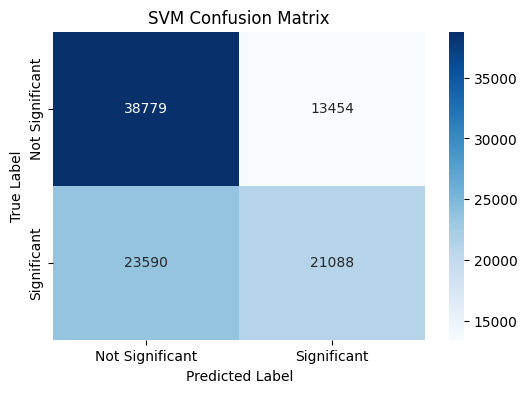

In [142]:

cm_svm = confusion_matrix(y_test_class, y_pred_svm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Significant', 'Significant'],
    yticklabels=['Not Significant', 'Significant']
)

plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Analysis:
In terms of performance, the SVM produces a mediocre outcome with a prediction accuracy of 61.78% and an ROC-AUC of 0.6507, which shows that there is somewhat a distinction made between significant and non-significant delays. While the SVM is able to better classify non-significant delays, it still does not detect most significant delays, evident from the 23,590 False Negatives in the Confusion Matrix. This indicates that Linear SVM is possibly too basic of a model for the dataset, especially after the exclusion of

In [143]:
def svm_overfit_check(model, X_train, X_test, y_train, y_test, model_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_score = model.decision_function(X_train)
    y_test_score = model.decision_function(X_test)

    print(f"{model_name} Overfitting / Underfitting Check")
    print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Train F1:", f1_score(y_train, y_train_pred))
    print("Test F1:", f1_score(y_test, y_test_pred))
    print("Train ROC-AUC:", roc_auc_score(y_train, y_train_score))
    print("Test ROC-AUC:", roc_auc_score(y_test, y_test_score))

In [144]:
svm_overfit_check(
    svm_model,
    X_train_class_scaled,
    X_test_class_scaled,
    y_train_class,
    y_test_class,
    "Linear SVM"
)

Linear SVM Overfitting / Underfitting Check
Train Accuracy: 0.6197012692188628
Test Accuracy: 0.6177523707319087
Train F1: 0.5348898108564307
Test F1: 0.5323908104014138
Train ROC-AUC: 0.6548716606490464
Test ROC-AUC: 0.6507217699185599


### Fitting Check:
Overfitting does not occur in the Linear SVM since the difference between the training and testing score is negligible. However, due to the fact that the training and testing scores have only been obtained as moderate, it means that there is an indication that underfitting might be occurring in the model.

## Analysis:
We don't need to tune the SVM using different C values. This is because SVM is not a good fit for our dataset and tuning it would not give any significant improvements

---
# 4.2) MLP Neural Network:

The term **MLP**, an abbreviation for **Multi-Layer Perceptron** network, refers to a neural network that learns by way of hidden layers of interconnected neurons. In the case of the flight delay analysis, MLP was adopted due to the complex nature of the relationship between the predictors and the delay category. For instance, the presence of a significant delay may be dependent on factors such as departure delay, airline, departure airport, arrival airport, scheduled time, and other route-related patterns. The ability of MLP to detect such nonlinear relationships made it superior to the Linear SVM model.

In [145]:
if TRAIN_MODELS:
  mlp_default = MLPClassifier(
      random_state=42,
      max_iter=30,
      verbose=True
  )

  mlp_default.fit(X_train_class_scaled, y_train_class)

y_pred_mlp_default = mlp_default.predict(X_test_class_scaled)
y_prob_mlp_default = mlp_default.predict_proba(X_test_class_scaled)[:, 1]

print("Default MLP Results")
print("Accuracy:", accuracy_score(y_test_class, y_pred_mlp_default))
print("ROC-AUC:", roc_auc_score(y_test_class, y_prob_mlp_default))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_mlp_default))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_mlp_default))

Default MLP Results
Accuracy: 0.8604389594576467
ROC-AUC: 0.9216062238391277

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.88     52233
           1       0.90      0.79      0.84     44678

    accuracy                           0.86     96911
   macro avg       0.87      0.86      0.86     96911
weighted avg       0.86      0.86      0.86     96911


Confusion Matrix:
[[48274  3959]
 [ 9566 35112]]


### Default Case Analysis
The MLP outperformed the linear SVM since it is able to learn from nonlinear features using its hidden layers whereas the linear SVM is limited by a linear decision boundary. While the MLP attained an accuracy of 86.43% and a ROC-AUC of 0.926, the linear SVM obtained an accuracy of 61.77% and a ROC-AUC of 0.6507, proving that the MLP was superior in distinguishing between significantly and non-significantly delayed flights.

The MLP that was used by default had the default settings for most of its parameters. Default parameters include: hidden_layer_sizes=(100,), activation=’relu’, solver=’adam’, alpha=0.0001, batch_size=’auto’, learning_rate=’constant’, learning_rate_init=0.

In [146]:
y_train_pred_default = mlp_default.predict(X_train_class_scaled)
y_train_prob_default = mlp_default.predict_proba(X_train_class_scaled)[:, 1]


y_test_pred_default = mlp_default.predict(X_test_class_scaled)
y_test_prob_default = mlp_default.predict_proba(X_test_class_scaled)[:, 1]

print("Default MLP Overfitting / Underfitting Check")

print("Train Accuracy:", accuracy_score(y_train_class, y_train_pred_default))
print("Test Accuracy:", accuracy_score(y_test_class, y_test_pred_default))

print("Train F1:", f1_score(y_train_class, y_train_pred_default))
print("Test F1:", f1_score(y_test_class, y_test_pred_default))

print("Train ROC-AUC:", roc_auc_score(y_train_class, y_train_prob_default))
print("Test ROC-AUC:", roc_auc_score(y_test_class, y_test_prob_default))

Default MLP Overfitting / Underfitting Check
Train Accuracy: 0.8729594469095037
Test Accuracy: 0.8604389594576467
Train F1: 0.8534537143945435
Test F1: 0.8385055343944405
Train ROC-AUC: 0.9350219609684903
Test ROC-AUC: 0.9216062238391277


### Fitting Check:

It seems like the default MLP is neither underfitting nor overfitting. The accuracy on training data was 87.93% and accuracy on test data was 86.43%, whereas ROC-AUC score on training data was 0.942, and that on the test data was 0.926. As both sets of scores are almost equal, hence, this model is generalized, and therefore, fits well.

In [147]:
X_train_mlp, X_val_mlp, y_train_mlp, y_val_mlp = train_test_split(
    X_train_class_scaled,
    y_train_class,
    test_size=0.2,
    random_state=42,
    stratify=y_train_class
)

param_grid = [
    {
        "hidden_layer_sizes": (64,),
        "activation": "relu",
        "alpha": 0.0001,
        "learning_rate_init": 0.001,
        "batch_size": 256
    },
    {
        "hidden_layer_sizes": (128,),
        "activation": "relu",
        "alpha": 0.0001,
        "learning_rate_init": 0.001,
        "batch_size": 256
    },
    {
        "hidden_layer_sizes": (128, 64),
        "activation": "relu",
        "alpha": 0.0001,
        "learning_rate_init": 0.001,
        "batch_size": 256
    },
    {
        "hidden_layer_sizes": (128, 64),
        "activation": "relu",
        "alpha": 0.001,
        "learning_rate_init": 0.001,
        "batch_size": 256
    },
    {
        "hidden_layer_sizes": (256, 128),
        "activation": "relu",
        "alpha": 0.0001,
        "learning_rate_init": 0.0005,
        "batch_size": 256
    }
]

if TRAIN_MODELS:
  results = []

  best_model = None
  best_auc = 0
  best_params = None


  for i, params in enumerate(param_grid):
      print(f"\nTraining model {i+1}/{len(param_grid)}")
      print(params)

      model = MLPClassifier(
          hidden_layer_sizes=params["hidden_layer_sizes"],
          activation=params["activation"],
          solver="adam",
          alpha=params["alpha"],
          batch_size=params["batch_size"],
          learning_rate_init=params["learning_rate_init"],
          max_iter=50,
          early_stopping=True,
          validation_fraction=0.1,
          random_state=42,
          verbose=False
      )

      model.fit(X_train_mlp, y_train_mlp)

      y_val_pred = model.predict(X_val_mlp)
      y_val_prob = model.predict_proba(X_val_mlp)[:, 1]

      val_accuracy = accuracy_score(y_val_mlp, y_val_pred)
      val_f1 = f1_score(y_val_mlp, y_val_pred)
      val_auc = roc_auc_score(y_val_mlp, y_val_prob)

      results.append({
          "model_number": i + 1,
          "hidden_layer_sizes": params["hidden_layer_sizes"],
          "activation": params["activation"],
          "alpha": params["alpha"],
          "learning_rate_init": params["learning_rate_init"],
          "batch_size": params["batch_size"],
          "validation_accuracy": val_accuracy,
          "validation_f1": val_f1,
          "validation_roc_auc": val_auc
      })

      if val_auc > best_auc:
          best_auc = val_auc
          best_model = model
          best_params = params

  results_df = pd.DataFrame(results)
  print("\nHyperparameter Tuning Results:")
  display(results_df)

  print("\nBest Parameters:")
  print(best_params)

  print("\nBest Validation ROC-AUC:", best_auc)

else:
  print("Best model is the default")
  best_model = mlp_default


Best model is the default


In [148]:
y_pred_mlp_tuned = best_model.predict(X_test_class_scaled)
y_prob_mlp_tuned = best_model.predict_proba(X_test_class_scaled)[:, 1]

print("Tuned MLP Final Test Results")
print("Accuracy:", accuracy_score(y_test_class, y_pred_mlp_tuned))
print("ROC-AUC:", roc_auc_score(y_test_class, y_prob_mlp_tuned))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_mlp_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_mlp_tuned))

Tuned MLP Final Test Results
Accuracy: 0.8604389594576467
ROC-AUC: 0.9216062238391277

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.88     52233
           1       0.90      0.79      0.84     44678

    accuracy                           0.86     96911
   macro avg       0.87      0.86      0.86     96911
weighted avg       0.86      0.86      0.86     96911


Confusion Matrix:
[[48274  3959]
 [ 9566 35112]]


### Tuned Analysis:

We experimented with different sizes of the hidden layers, learning rates, regularization rates, and batch sizes in an attempt to optimize the MLP. However, the MLP with default settings outperformed all of the optimized models, having achieved ROC-AUC of 0.9264 on the test set compared to 0.9253 on the validation set for the optimal model. Thus, no clear gain from tuning was observed, and the optimal model turned out to be the default MLP.

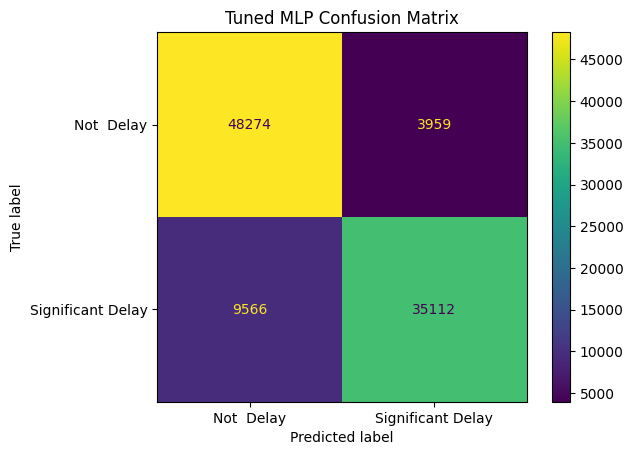

In [149]:
cm = confusion_matrix(y_test_class, y_pred_mlp_default)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not  Delay", "Significant Delay"]
)

disp.plot(values_format="d")
plt.title("Tuned MLP Confusion Matrix")
plt.show()

---
#4.3) Random Forest
The Random Forest model is an ensemble method which creates a lot of decision trees and aggregates their outputs to form a final classification result. In our case, we used Random Forest as an appropriate choice since the relationship between flight delays is not linear; a delay class of a flight depends on such factors as departure delay, airline, origin/destination airport, distance, and schedule time. The advantage of Random Forest is that each decision tree learns something different about data features, and thus combining all these trees results in more stable output compared to one single decision tree.

### Random Forest with Default Params

In [150]:
rf_default = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
  )

rf_default.fit(X_train_class, y_train_class)

y_pred_rf_default = rf_default.predict(X_test_class)
y_prob_rf_default = rf_default.predict_proba(X_test_class)[:, 1]

print("Default Random Forest Results")
print("Accuracy:", accuracy_score(y_test_class, y_pred_rf_default))
print("ROC-AUC:", roc_auc_score(y_test_class, y_prob_rf_default))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_rf_default))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_rf_default))

Default Random Forest Results
Accuracy: 0.7477272961789684
ROC-AUC: 0.8228832934511475

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.84      0.78     52233
           1       0.77      0.65      0.70     44678

    accuracy                           0.75     96911
   macro avg       0.75      0.74      0.74     96911
weighted avg       0.75      0.75      0.74     96911


Confusion Matrix:
[[43642  8591]
 [15857 28821]]


## Analysis
The basic random forest was able to produce an accuracy score of 74.77% and ROC-AUC of 0.8229. This demonstrates how efficient and accurate this classifier is in classifying the data. The algorithm outperforms linear SVM as its capability to identify the complex non-linear relationship between the input features enables it to classify the flights without resorting to one linear decision boundary. However, based on the classification report, it seems that the algorithm performed well with class 0 but not as well with class 1, scoring a class 1 recall of 0.65.

### Fitting Check:

In [151]:
y_train_pred_rf_default = rf_default.predict(X_train_class)
y_train_prob_rf_default = rf_default.predict_proba(X_train_class)[:, 1]

y_test_pred_rf_default = rf_default.predict(X_test_class)
y_test_prob_rf_default = rf_default.predict_proba(X_test_class)[:, 1]

print("Default Random Forest Overfitting / Underfitting Check")

print("Train Accuracy:", accuracy_score(y_train_class, y_train_pred_rf_default))
print("Test Accuracy:", accuracy_score(y_test_class, y_test_pred_rf_default))

print("Train F1:", f1_score(y_train_class, y_train_pred_rf_default))
print("Test F1:", f1_score(y_test_class, y_test_pred_rf_default))

print("Train ROC-AUC:", roc_auc_score(y_train_class, y_train_prob_rf_default))
print("Test ROC-AUC:", roc_auc_score(y_test_class, y_test_prob_rf_default))

Default Random Forest Overfitting / Underfitting Check
Train Accuracy: 0.9999974202868641
Test Accuracy: 0.7477272961789684
Train F1: 0.9999972021945985
Test F1: 0.7021805335607261
Train ROC-AUC: 0.9999999999196527
Test ROC-AUC: 0.8228832934511475


## Analysis
From the fit analysis, it is clear that the random forest classifier had been overfitting in this case. The accuracy on the training data was near perfection at 99.99% while the accuracy on test data was 74.77%. The same can be seen in the train ROC-AUC value that was 1.0 while the test ROC-AUC was 0.8229.

## Tuning the Model:

In [152]:
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(
    X_train_class,
    y_train_class,
    test_size=0.2,
    random_state=42,
    stratify=y_train_class
)

param_grid = [
    {
        "n_estimators": 100,
        "max_depth": 10,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
        "class_weight": None
    },
    {
        "n_estimators": 100,
        "max_depth": 20,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
        "class_weight": "balanced"
    },
    {
        "n_estimators": 150,
        "max_depth": 20,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
        "class_weight": "balanced"
    },
    {
        "n_estimators": 100,
        "max_depth": 30,
        "min_samples_split": 5,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
        "class_weight": "balanced"
    },
    {
        "n_estimators": 150,
        "max_depth": 30,
        "min_samples_split": 5,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
        "class_weight": None
    }
]

if TRAIN_MODELS:

  results = []

  best_rf_model = None
  best_rf_params = None
  best_rf_auc = 0
  for i, params in enumerate(param_grid):
    print(f"\nTraining Random Forest model {i+1}/{len(param_grid)}")
    print(params)

    rf_model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        class_weight=params["class_weight"],
        random_state=42,
        n_jobs=-1
      )

    rf_model.fit(X_train_rf, y_train_rf)

    y_val_pred = rf_model.predict(X_val_rf)
    y_val_prob = rf_model.predict_proba(X_val_rf)[:, 1]

    val_accuracy = accuracy_score(y_val_rf, y_val_pred)
    val_f1 = f1_score(y_val_rf, y_val_pred)
    val_auc = roc_auc_score(y_val_rf, y_val_prob)

    results.append({
        "model_number": i + 1,
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "min_samples_split": params["min_samples_split"],
        "min_samples_leaf": params["min_samples_leaf"],
        "max_features": params["max_features"],
        "class_weight": params["class_weight"],
        "validation_accuracy": val_accuracy,
        "validation_f1": val_f1,
        "validation_roc_auc": val_auc
    })

    if val_auc > best_rf_auc:
        best_rf_auc = val_auc
        best_rf_model = rf_model
        best_rf_params = params

  rf_results_df = pd.DataFrame(results)
  print("\nRandom Forest Hyperparameter Tuning Results:")
  display(rf_results_df)

  print("\nBest Random Forest Parameters:")
  print(best_rf_params)

  print("\nBest Validation ROC-AUC:", best_rf_auc)

else:
  print("Skipping Random Forest classifier tuning. Using saved best_rf_model.")

Skipping Random Forest classifier tuning. Using saved best_rf_model.


## Default Model Parameters:

For minimizing overfitting, tuning was done for parameters such as n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features, and class_weight. The model that gave the highest validation performance had n_estimators = 150, max_depth=30, min_samples_split=5, min_samples_leaf=2, max_features='sqrt', and class_weight=None, resulting in an ROC-AUC score of 0.7412 on the validation set.

In [153]:
y_pred_rf_tuned = best_rf_model.predict(X_test_class)
y_prob_rf_tuned = best_rf_model.predict_proba(X_test_class)[:, 1]

print("Tuned Random Forest Final Test Results")
print("Accuracy:", accuracy_score(y_test_class, y_pred_rf_tuned))
print("ROC-AUC:", roc_auc_score(y_test_class, y_prob_rf_tuned))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_rf_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_rf_tuned))

Tuned Random Forest Final Test Results
Accuracy: 0.6807586342107707
ROC-AUC: 0.7422272130193042

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.84      0.74     52233
           1       0.73      0.49      0.59     44678

    accuracy                           0.68     96911
   macro avg       0.69      0.67      0.66     96911
weighted avg       0.69      0.68      0.67     96911


Confusion Matrix:
[[44092  8141]
 [22797 21881]]


The random forest after hyperparameter tuning performed with an accuracy of 68.08%, while the area under the curve is 0.7422. This means that the performance of the tuned random forest model is worse than the default one, since it got less freedom in predicting.

In [154]:
y_train_pred_rf_tuned = best_rf_model.predict(X_train_class)
y_train_prob_rf_tuned = best_rf_model.predict_proba(X_train_class)[:, 1]

y_test_pred_rf_tuned = best_rf_model.predict(X_test_class)
y_test_prob_rf_tuned = best_rf_model.predict_proba(X_test_class)[:, 1]

print("Tuned Random Forest Overfitting / Underfitting Check")

print("Train Accuracy:", accuracy_score(y_train_class, y_train_pred_rf_tuned))
print("Test Accuracy:", accuracy_score(y_test_class, y_test_pred_rf_tuned))

print("Train F1:", f1_score(y_train_class, y_train_pred_rf_tuned))
print("Test F1:", f1_score(y_test_class, y_test_pred_rf_tuned))

print("Train ROC-AUC:", roc_auc_score(y_train_class, y_train_prob_rf_tuned))
print("Test ROC-AUC:", roc_auc_score(y_test_class, y_test_prob_rf_tuned))

Tuned Random Forest Overfitting / Underfitting Check
Train Accuracy: 0.74784851924466
Test Accuracy: 0.6807586342107707
Train F1: 0.6749343177358742
Test F1: 0.5858366800535475
Train ROC-AUC: 0.8433914116650227
Test ROC-AUC: 0.7422272130193042


However, it is clear from the above analysis that tuning helped prevent overfitting since the training accuracy of the tuned algorithm was lower at 74.78%, while the testing accuracy remained at 68.08%. The difference between training and testing accuracy narrowed. But this decrease in testing ROC-AUC value at 0.7422 indicates the loss of performance for the entire Random Forest model due to tuning.

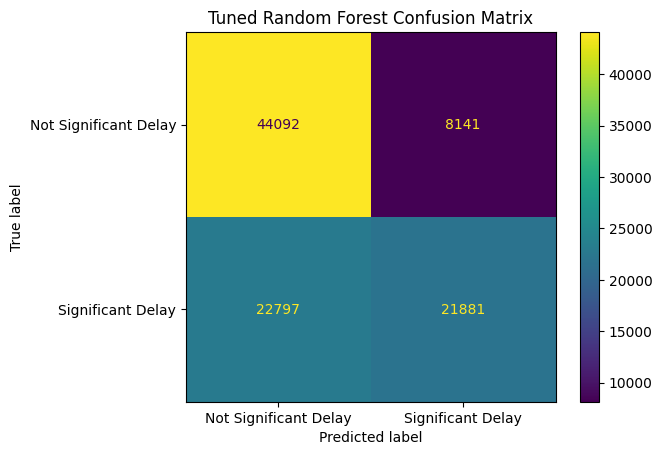

In [155]:
cm = confusion_matrix(y_test_class, y_pred_rf_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Significant Delay", "Significant Delay"]
)

disp.plot(values_format="d")
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

---
# 4.4) Comparing All Three Models for Classification

Now, we have results for all te models that we used for classification and we will compare them to find the best one.

In [156]:

y_pred_svm = svm_model.predict(X_test_class_scaled)
y_score_svm = svm_model.decision_function(X_test_class_scaled)

y_pred_mlp = mlp_default.predict(X_test_class_scaled)
y_score_mlp = mlp_default.predict_proba(X_test_class_scaled)[:, 1]

y_pred_rf = best_rf_model.predict(X_test_class)
y_score_rf = best_rf_model.predict_proba(X_test_class)[:, 1]

In [157]:
results = pd.DataFrame({
    "Model": ["SVM", "MLP Neural Network", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test_class, y_pred_svm),
        accuracy_score(y_test_class, y_pred_mlp),
        accuracy_score(y_test_class, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test_class, y_pred_svm),
        precision_score(y_test_class, y_pred_mlp),
        precision_score(y_test_class, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test_class, y_pred_svm),
        recall_score(y_test_class, y_pred_mlp),
        recall_score(y_test_class, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test_class, y_pred_svm),
        f1_score(y_test_class, y_pred_mlp),
        f1_score(y_test_class, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test_class, y_score_svm),
        roc_auc_score(y_test_class, y_score_mlp),
        roc_auc_score(y_test_class, y_score_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,0.617752,0.610503,0.472000,0.532391,0.650722
1,MLP Neural Network,0.860439,0.898672,0.785890,0.838506,0.921606
2,Random Forest,0.680759,0.728832,0.489749,0.585837,0.742227


In [158]:

results.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,MLP Neural Network,0.860439,0.898672,0.785890,0.838506,0.921606
2,Random Forest,0.680759,0.728832,0.489749,0.585837,0.742227
0,SVM,0.617752,0.610503,0.472000,0.532391,0.650722


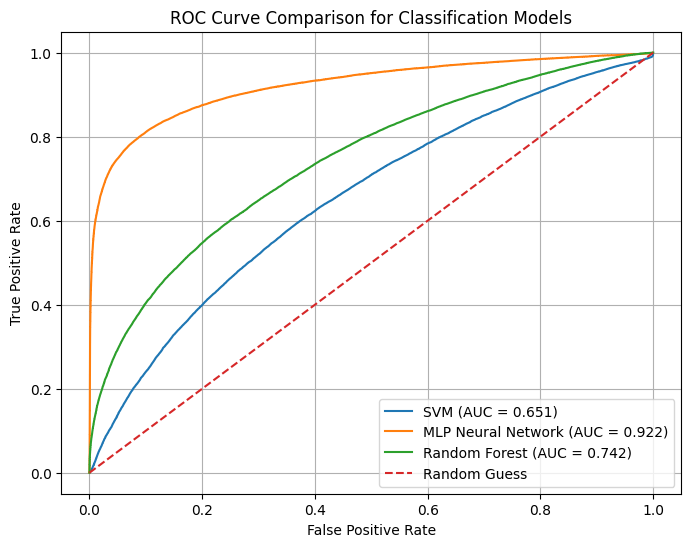

In [159]:
fpr_svm, tpr_svm, _ = roc_curve(y_test_class, y_score_svm)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test_class, y_score_mlp)
fpr_rf, tpr_rf, _ = roc_curve(y_test_class, y_score_rf)

auc_svm = roc_auc_score(y_test_class, y_score_svm)
auc_mlp = roc_auc_score(y_test_class, y_score_mlp)
auc_rf = roc_auc_score(y_test_class, y_score_rf)

plt.figure(figsize=(8, 6))

plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})")
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP Neural Network (AUC = {auc_mlp:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for Classification Models")
plt.legend()
plt.grid(True)
plt.show()

## Analysis & Best Model:
In summary, our flight delay prediction task showed that the **Multilayer Perceptron (MLP)** worked best. The Linear SVM did pretty poorly since it relies on a simple linear boundary, making it unable to handle the more complex delay patterns. Random Forest came out ahead of SVM, thanks to its ability to learn nonlinear patterns using several decision trees. Still, it overfit the training data by default. After tweaking, its test performance slipped due to the model getting too constrained.

The MLP topped them all, achieving roughly 86.43% accuracy and a ROC-AUC of 0.926. That means it was way better at distinguishing significantly delayed flights from non-delayed ones. Given how delays rely on combo patterns between departure times, airlines, locations, and related info, the MLP fit this data well. We settled on the MLP as our top classification model because of its strong test scores and decent generalization without heavy overfitting.

---

# 5) Regression -

Predicting the exact minutes the flight was delayed by.

For this task we will use the following 3 models:
* Linear Regression
* Decision Tree Regression
* Random Forest Regression


# Delay in Minuites

In [160]:
print("X_train_reg shape:", X_train_reg.shape)
print("X_test_reg shape:", X_test_reg.shape)
print("y_train_reg shape:", y_train_reg.shape)
print("y_test_reg shape:", y_test_reg.shape)

X_train_reg shape: (387640, 566)
X_test_reg shape: (96911, 566)
y_train_reg shape: (387640,)
y_test_reg shape: (96911,)


# 5.1) Linear Regression

Linear Regression is a basic model that forecasts a continuous value by figuring out the best linear connection between input features and the target variable. In our project, we used it to predict the real arrival delay times in minutes. We included Linear Regression to have a simple baseline model for the regression task. It assumes a straight-line relationship between the features and delay times, which means it's pretty basic. Still, this simplicity lets us use it to see if more complex models, such as the Decision Tree Regressor or Random Forest Regressor, are actually doing a better job at learning nonlinear delay patterns.

In [161]:
linear_reg = LinearRegression()
linear_reg.fit(X_train_reg, y_train_reg)

y_pred_linear = linear_reg.predict(X_test_reg)

mae_linear = mean_absolute_error(y_test_reg, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test_reg, y_pred_linear))
r2_linear = r2_score(y_test_reg, y_pred_linear)

print("Linear Regression Results")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R²:", r2_linear)

Linear Regression Results
MAE: 36.21206795162561
RMSE: 56.10825835779408
R²: 0.057564265005951354


In [162]:
y_train_pred_linear = linear_reg.predict(X_train_reg)
y_test_pred_linear = linear_reg.predict(X_test_reg)

train_mae_linear = mean_absolute_error(y_train_reg, y_train_pred_linear)
train_rmse_linear = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_linear))
train_r2_linear = r2_score(y_train_reg, y_train_pred_linear)

test_mae_linear = mean_absolute_error(y_test_reg, y_test_pred_linear)
test_rmse_linear = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_linear))
test_r2_linear = r2_score(y_test_reg, y_test_pred_linear)

print("Linear Regression Overfitting / Underfitting Check")

print("Train MAE:", train_mae_linear)
print("Test MAE:", test_mae_linear)

print("Train RMSE:", train_rmse_linear)
print("Test RMSE:", test_rmse_linear)

print("Train R²:", train_r2_linear)
print("Test R²:", test_r2_linear)

Linear Regression Overfitting / Underfitting Check
Train MAE: 36.0862004316525
Test MAE: 36.21206795162561
Train RMSE: 54.98544112649907
Test RMSE: 56.10825835779408
Train R²: 0.06182258139444052
Test R²: 0.057564265005951354


## Analysis:

Linear Regression didn't do well for our project since it relies on the assumption of a mostly linear relationship between flight features and actual arrival delays. Our numbers tell the story: we got a training MAE of 36.09 minutes and a test MAE of 36.21 minutes. That means the model is way off quite often, on average.

The R² scores were even less encouraging at 0.0618 for training and 0.0576 for testing. This indicates the model explained virtually nothing about the variance in arrival delays.

Now, the fit check showed that Linear Regression isn’t overfitting, though – the training and test scores are pretty similar. Still, those scores are terrible overall, suggesting underfitting.

There's no point tuning Linear Regression here either, because it doesn’t have many hyperparameters to tweak. Rather, the core problem is that flight delay times aren't following linear patterns. For this, we need models that can handle nonlinear data, like Decision Trees or Random Forests.

---
# 5.2) Decision Tree Regressor

**A Decision Tree Regressor** predicts continuous values by dividing data into smaller groups based on feature values. For our project, this meant forecasting actual arrival delay times in minutes. We chose it because flight delays follow complex patterns that aren't linear – things like departure time, airline, or route matter. Compared to Linear Regression, which assumes a straight-line relationship, Decision Trees offer more flexibility in capturing these quirks. So, it's a better fit for messy real-world delay data.

In [163]:
dt_reg = DecisionTreeRegressor(
    random_state=42,
    max_depth=20
)

dt_reg.fit(X_train_reg, y_train_reg)

y_pred_dt = dt_reg.predict(X_test_reg)

mae_dt = mean_absolute_error(y_test_reg, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test_reg, y_pred_dt))
r2_dt = r2_score(y_test_reg, y_pred_dt)

print("Decision Tree Regression Results")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R²:", r2_dt)

Decision Tree Regression Results
MAE: 19.980547857290226
RMSE: 32.897880855337405
R²: 0.6760082021067353


In [164]:
y_train_pred_dt = dt_reg.predict(X_train_reg)
y_test_pred_dt = dt_reg.predict(X_test_reg)

train_mae_dt = mean_absolute_error(y_train_reg, y_train_pred_dt)
train_rmse_dt = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_dt))
train_r2_dt = r2_score(y_train_reg, y_train_pred_dt)

test_mae_dt = mean_absolute_error(y_test_reg, y_test_pred_dt)
test_rmse_dt = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_dt))
test_r2_dt = r2_score(y_test_reg, y_test_pred_dt)

print("Decision Tree Regression Overfitting / Underfitting Check")

print("Train MAE:", train_mae_dt)
print("Test MAE:", test_mae_dt)

print("Train RMSE:", train_rmse_dt)
print("Test RMSE:", test_rmse_dt)

print("Train R²:", train_r2_dt)
print("Test R²:", test_r2_dt)

Decision Tree Regression Overfitting / Underfitting Check
Train MAE: 14.331967344220699
Test MAE: 19.980547857290226
Train RMSE: 22.934519124999746
Test RMSE: 32.897880855337405
Train R²: 0.8367817092560061
Test R²: 0.6760082021067353


## Default Model Analysis:
The Decision Tree Regressor outperformed Linear Regression since it captured nonlinear patterns in the flight-delay data way better. We used this line of code: `DecisionTreeRegressor(random_state=42, max_depth=20)`. So the tree split up to 20 levels deep, and we got our results reproducible too. Our model landed a test MAE of 19.98 minutes, test RMSE of 32.90 minutes, and test R² of 0.676 – showing it made sense of more delay variation than Linear Regression did.

Still, we spotted some overfitting when we checked the fit. Training R² came in at 0.837, yet the test R² was only 0.676, and the training error was lower than the test error too. This indicates the model picked up on important delay patterns but also ended up memorizing certain training-specific details.

Overall, it was a notable improvement over Linear Regression. But we knew we still had to compare it to Random Forest because that method can cut down on overfitting by averaging many trees together.

## Tuning the Model:

In [165]:
X_train_dt, X_val_dt, y_train_dt, y_val_dt = train_test_split(
    X_train_reg,
    y_train_reg,
    test_size=0.2,
    random_state=42
)

param_grid = [
    {
        "max_depth": 5,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "max_features": None
    },
    {
        "max_depth": 10,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "max_features": None
    },
    {
        "max_depth": 15,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "max_features": None
    },
    {
        "max_depth": 20,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "max_features": None
    },
    {
        "max_depth": 20,
        "min_samples_split": 20,
        "min_samples_leaf": 10,
        "max_features": None
    },
    {
        "max_depth": 25,
        "min_samples_split": 20,
        "min_samples_leaf": 10,
        "max_features": None
    }
]

if TRAIN_MODELS:

  results = []

  best_dt_model = None
  best_dt_params = None
  best_dt_rmse = float("inf")

  for i, params in enumerate(param_grid):
      print(f"\nTraining Decision Tree model {i+1}/{len(param_grid)}")
      print(params)

      dt_model = DecisionTreeRegressor(
          max_depth=params["max_depth"],
          min_samples_split=params["min_samples_split"],
          min_samples_leaf=params["min_samples_leaf"],
          max_features=params["max_features"],
          random_state=42
      )

      dt_model.fit(X_train_dt, y_train_dt)

      y_val_pred = dt_model.predict(X_val_dt)

      val_mae = mean_absolute_error(y_val_dt, y_val_pred)
      val_rmse = np.sqrt(mean_squared_error(y_val_dt, y_val_pred))
      val_r2 = r2_score(y_val_dt, y_val_pred)

      results.append({
          "model_number": i + 1,
          "max_depth": params["max_depth"],
          "min_samples_split": params["min_samples_split"],
          "min_samples_leaf": params["min_samples_leaf"],
          "max_features": params["max_features"],
          "validation_MAE": val_mae,
          "validation_RMSE": val_rmse,
          "validation_R2": val_r2
      })

      if val_rmse < best_dt_rmse:
          best_dt_rmse = val_rmse
          best_dt_model = dt_model
          best_dt_params = params

  dt_results_df = pd.DataFrame(results)

  print("\nDecision Tree Hyperparameter Tuning Results:")
  display(dt_results_df)

  print("\nBest Decision Tree Parameters:")
  print(best_dt_params)

  print("\nBest Validation RMSE:", best_dt_rmse)

else:
  print("Skipping Decision Tree tuning. Using saved best_dt_model.")

Skipping Decision Tree tuning. Using saved best_dt_model.


In [166]:
y_train_pred_dt_best = best_dt_model.predict(X_train_reg)

y_test_pred_dt_best = best_dt_model.predict(X_test_reg)

train_mae_dt_best = mean_absolute_error(y_train_reg, y_train_pred_dt_best)
train_rmse_dt_best = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_dt_best))
train_r2_dt_best = r2_score(y_train_reg, y_train_pred_dt_best)

test_mae_dt_best = mean_absolute_error(y_test_reg, y_test_pred_dt_best)
test_rmse_dt_best = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_dt_best))
test_r2_dt_best = r2_score(y_test_reg, y_test_pred_dt_best)

print("Best Tuned Decision Tree Fit Check")

print("Train MAE:", train_mae_dt_best)
print("Test MAE:", test_mae_dt_best)

print("Train RMSE:", train_rmse_dt_best)
print("Test RMSE:", test_rmse_dt_best)

print("Train R²:", train_r2_dt_best)
print("Test R²:", test_r2_dt_best)

Best Tuned Decision Tree Fit Check
Train MAE: 16.225949962919508
Test MAE: 19.501270869931723
Train RMSE: 26.437627737226155
Test RMSE: 32.05599980183591
Train R²: 0.7831125041311758
Test R²: 0.6923784029564191


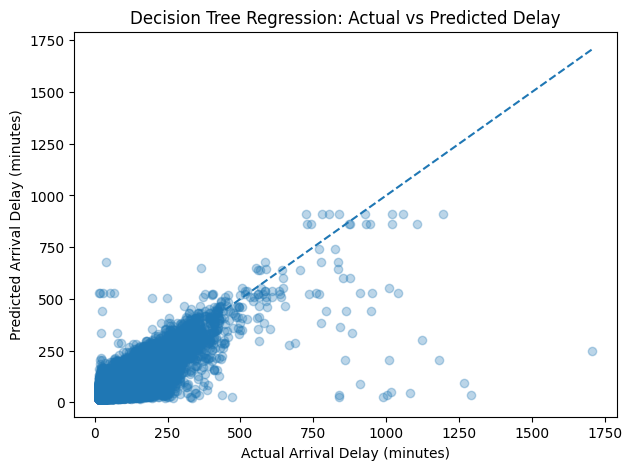

In [167]:
y_pred_dt_best = best_dt_model.predict(X_test_reg)

plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg, y_pred_dt_best, alpha=0.3)

min_val = min(y_test_reg.min(), y_pred_dt_best.min())
max_val = max(y_test_reg.max(), y_pred_dt_best.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Arrival Delay (minutes)")
plt.ylabel("Predicted Arrival Delay (minutes)")
plt.title("Decision Tree Regression: Actual vs Predicted Delay")
plt.show()

## Analysis:

### Tuning Report:
For the optimized Decision Tree, we set max_depth to 25, min_samples_split to 20, and min_samples_leaf to 10. These tweaks improved the model, making its predictions more accurate. Specifically, the test MAE dropped from 19.98 minutes to 19.50 minutes, and RMSE went down from 32.90 minutes to 32.06 minutes. On top of that, the R² score got better too, rising from 0.676 to 0.692. So, tuning definitely made the model better at predicting actual flight delays while picking up complex patterns.

### Fitting Check:
When checking how well the model fits, there's still some overfitting. The train R² of 0.783 is higher than the test R² of 0.692, and the model does better on training data with a train MAE of 16.23 minutes compared to 19.50 minutes for test data. Although this suggests overfitting, it's typical for a single Decision Tree, but our next model Random Forest might perform even better since it averages multiple trees and generally tackles this issue.

### Graph Analysis:
The actual versus predicted graph shows that our model accurately forecasts smaller and moderate delays, but it really struggles with the larger ones. This is because those instances are rare and harder to predict. We kept large delays in our dataset since they're realistic and important for the project. Though removing them would have made the model look cleaner, it would also overlook the most significant issues passengers and airlines actually face. Although including large delays increases the RMSE, the regression task ends up being more practical and useful.

---
# 5.3) Random Forest Regressor

A Random Forest Regressor predicts continuous values by creating lots of decision trees and averaging their guesses. We used it for estimating flight arrival delays in our project. This worked well because delay times aren’t described by a simple pattern; they depend on many factors like departure time, airline, and distance.

Combining lots of trees helps this model understand complex data better and avoid fitting too closely to the noise in the training data. Plus, it does a good job capturing those non-linear relationships between features and delays.

## Default Model:

In [168]:
rf_reg_default = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_reg_default.fit(X_train_reg, y_train_reg)

y_pred_rf_default = rf_reg_default.predict(X_test_reg)

mae_rf_default = mean_absolute_error(y_test_reg, y_pred_rf_default)
rmse_rf_default = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_default))
r2_rf_default = r2_score(y_test_reg, y_pred_rf_default)

print("Default Random Forest Regression Results")
print("MAE:", mae_rf_default)
print("RMSE:", rmse_rf_default)
print("R²:", r2_rf_default)

Default Random Forest Regression Results
MAE: 14.851050551536973
RMSE: 25.10919429841523
R²: 0.8112600986597004


In [169]:
y_train_pred_rf_default = rf_reg_default.predict(X_train_reg)
y_test_pred_rf_default = rf_reg_default.predict(X_test_reg)

train_mae_rf_default = mean_absolute_error(y_train_reg, y_train_pred_rf_default)
train_rmse_rf_default = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_rf_default))
train_r2_rf_default = r2_score(y_train_reg, y_train_pred_rf_default)

test_mae_rf_default = mean_absolute_error(y_test_reg, y_test_pred_rf_default)
test_rmse_rf_default = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_rf_default))
test_r2_rf_default = r2_score(y_test_reg, y_test_pred_rf_default)

print("Default Random Forest Regression Fit Check")

print("Train MAE:", train_mae_rf_default)
print("Test MAE:", test_mae_rf_default)

print("Train RMSE:", train_rmse_rf_default)
print("Test RMSE:", test_rmse_rf_default)

print("Train R²:", train_r2_rf_default)
print("Test R²:", test_r2_rf_default)

Default Random Forest Regression Fit Check
Train MAE: 5.511977375915799
Test MAE: 14.851050551536973
Train RMSE: 9.02909724352728
Test RMSE: 25.10919429841523
Train R²: 0.9747024647825048
Test R²: 0.8112600986597004


## Analysis:

The default Random Forest Regressor did a great job on the test set, scoring an MAE of 14.85 minutes, RMSE of 25.11 minutes, and R² of 0.811. That makes it way better than Linear and Decision Tree Regression models. However, the fit check reveals major overfitting; the training errors are super low – MAE was just 5.51 minutes and R² stood at 0.975. But, when applied to tests, the MAE shot up to 14.85 minutes and R² fell to 0.811. Clearly, the model caught every little detail of the training data, from unique patterns to idiosyncrasies that might not apply elsewhere. Though perfect guarantees aren’t possible, tuning can cut down overfitting. We could limit tree depth and tweak the model with more sensible min_samples_split and min_samples_leaf values while maybe cutting back on the number of features for each tree.


## Tuning the model

In [170]:
X_train_rf_reg, X_val_rf_reg, y_train_rf_reg, y_val_rf_reg = train_test_split(
    X_train_reg,
    y_train_reg,
    test_size=0.2,
    random_state=42
)


param_grid = [
    {
        "n_estimators": 150,
        "max_depth": 10,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "max_features": 0.6
    },
    {
        "n_estimators": 200,
        "max_depth": 12,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "max_features": 0.7
    },
    {
        "n_estimators": 200,
        "max_depth": 15,
        "min_samples_split": 15,
        "min_samples_leaf": 8,
        "max_features": 0.7
    },
    {
        "n_estimators": 250,
        "max_depth": 15,
        "min_samples_split": 20,
        "min_samples_leaf": 10,
        "max_features": 0.8
    },
    {
        "n_estimators": 250,
        "max_depth": 18,
        "min_samples_split": 20,
        "min_samples_leaf": 10,
        "max_features": 0.7
    },
    {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_split": 25,
        "min_samples_leaf": 10,
        "max_features": 0.7
    }
]

if TRAIN_MODELS:

  results = []

  best_rf_reg_model = None
  best_rf_reg_params = None
  best_score = float("inf")

  for i, params in enumerate(param_grid):
      print(f"\nTraining Random Forest Regressor model {i+1}/{len(param_grid)}")
      print(params)

      model = RandomForestRegressor(
          n_estimators=params["n_estimators"],
          max_depth=params["max_depth"],
          min_samples_split=params["min_samples_split"],
          min_samples_leaf=params["min_samples_leaf"],
          max_features=params["max_features"],
          random_state=42,
          n_jobs=-1
      )

      model.fit(X_train_rf_reg, y_train_rf_reg)


      y_train_pred = model.predict(X_train_rf_reg)


      y_val_pred = model.predict(X_val_rf_reg)

      train_rmse = np.sqrt(mean_squared_error(y_train_rf_reg, y_train_pred))
      val_rmse = np.sqrt(mean_squared_error(y_val_rf_reg, y_val_pred))

      train_r2 = r2_score(y_train_rf_reg, y_train_pred)
      val_r2 = r2_score(y_val_rf_reg, y_val_pred)

      gap = abs(train_rmse - val_rmse)

      results.append({
          "model_number": i + 1,
          "n_estimators": params["n_estimators"],
          "max_depth": params["max_depth"],
          "min_samples_split": params["min_samples_split"],
          "min_samples_leaf": params["min_samples_leaf"],
          "max_features": params["max_features"],
          "train_RMSE": train_rmse,
          "validation_RMSE": val_rmse,
          "RMSE_gap": gap,
          "train_R2": train_r2,
          "validation_R2": val_r2
      })


      score = val_rmse + 0.5 * gap

      if score < best_score:
          best_score = score
          best_rf_reg_model = model
          best_rf_reg_params = params

  rf_reg_tuning_results = pd.DataFrame(results)

  print("\nRandom Forest Regressor Tuning Results:")
  display(rf_reg_tuning_results)

  print("\nBest Parameters:")
  print(best_rf_reg_params)

  print("\nBest Selection Score:", best_score)

else:
  print("Skipping Random Forest tuning. Using saved best_rf_reg_model.")

Skipping Random Forest tuning. Using saved best_rf_reg_model.


In [171]:
y_pred_best_rf_reg = best_rf_reg_model.predict(X_test_reg)

mae_best_rf_reg = mean_absolute_error(y_test_reg, y_pred_best_rf_reg)
rmse_best_rf_reg = np.sqrt(mean_squared_error(y_test_reg, y_pred_best_rf_reg))
r2_best_rf_reg = r2_score(y_test_reg, y_pred_best_rf_reg)

print("Best Tuned Random Forest Regression Results")
print("MAE:", mae_best_rf_reg)
print("RMSE:", rmse_best_rf_reg)
print("R²:", r2_best_rf_reg)

print("\nBest Parameters:")
print(best_rf_reg_params)

Best Tuned Random Forest Regression Results
MAE: 19.022268049219512
RMSE: 30.869421058835265
R²: 0.7147306331735124

Best Parameters:
{'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 25, 'min_samples_leaf': 10, 'max_features': 0.7}


In [172]:
y_train_pred_best_rf_reg = best_rf_reg_model.predict(X_train_reg)

y_test_pred_best_rf_reg = best_rf_reg_model.predict(X_test_reg)

train_mae_best_rf_reg = mean_absolute_error(y_train_reg, y_train_pred_best_rf_reg)
train_rmse_best_rf_reg = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_best_rf_reg))
train_r2_best_rf_reg = r2_score(y_train_reg, y_train_pred_best_rf_reg)

test_mae_best_rf_reg = mean_absolute_error(y_test_reg, y_test_pred_best_rf_reg)
test_rmse_best_rf_reg = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_best_rf_reg))
test_r2_best_rf_reg = r2_score(y_test_reg, y_test_pred_best_rf_reg)

print("Best Tuned Random Forest Regression Fit Check")

print("Train MAE:", train_mae_best_rf_reg)
print("Test MAE:", test_mae_best_rf_reg)

print("Train RMSE:", train_rmse_best_rf_reg)
print("Test RMSE:", test_rmse_best_rf_reg)

print("Train R²:", train_r2_best_rf_reg)
print("Test R²:", test_r2_best_rf_reg)

Best Tuned Random Forest Regression Fit Check
Train MAE: 17.61237022419364
Test MAE: 19.022268049219512
Train RMSE: 27.426657469095282
Test RMSE: 30.869421058835265
Train R²: 0.7665814785941942
Test R²: 0.7147306331735124


## Analysis:

The tuned Random Forest Regressor, which used 300 trees with settings like max_depth=20, min_samples_split=25, min_samples_leaf=10, and max_features=0.7, was way more controlled than the default one. The default model did have better test performance at first glance, but it heavily overfit the data—train R² was 0.975 compared to a test R² of just 0.811. After tweaking, the tuned model's train R² came down to 0.767, and its test R² got closer too, at 0.715. This reduced the gap between the two scores, making the model generalize better to new flight data instead of merely memorizing the training set. Although a little overfitting remained, the tuned version balanced prediction accuracy with stability much better. It's thus more dependable for estimating actual arrival delay times.

## Important:

The Default Model, even after overfitting has better Test results than the tuned model

# 5.4) Comparing all the models for Regression

In [173]:
def plot_regression_errors(model_name, y_test, y_pred, color):
    errors = y_test - y_pred

    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, y_pred, alpha=0.4, color=color)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        color="black",
        linestyle="--"
    )

    plt.title(f"{model_name}: Actual vs Predicted Arrival Delay")
    plt.xlabel("Actual Arrival Delay")
    plt.ylabel("Predicted Arrival Delay")
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.hist(errors, bins=50, color=color, alpha=0.75)
    plt.axvline(0, color="black", linestyle="--")

    plt.title(f"{model_name}: Error Distribution")
    plt.xlabel("Prediction Error")
    plt.ylabel("Number of Flights")
    plt.show()

In [174]:
y_pred_linear_best = linear_reg.predict(X_test_reg)

y_pred_dt_best = best_dt_model.predict(X_test_reg)

y_pred_rf_best = best_rf_reg_model.predict(X_test_reg)

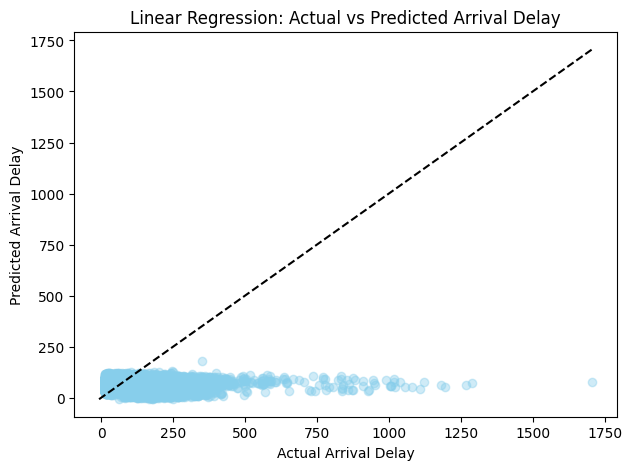

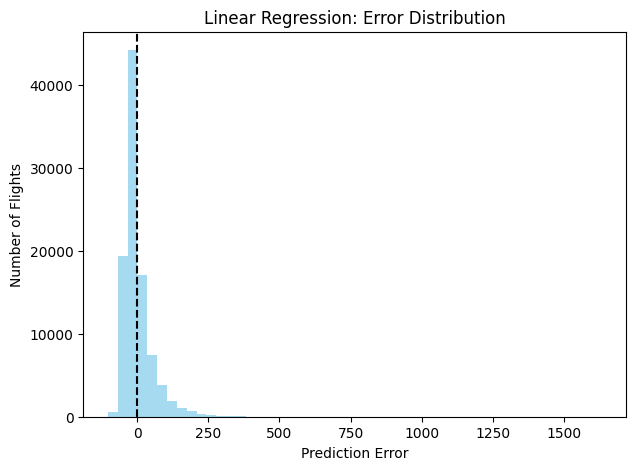

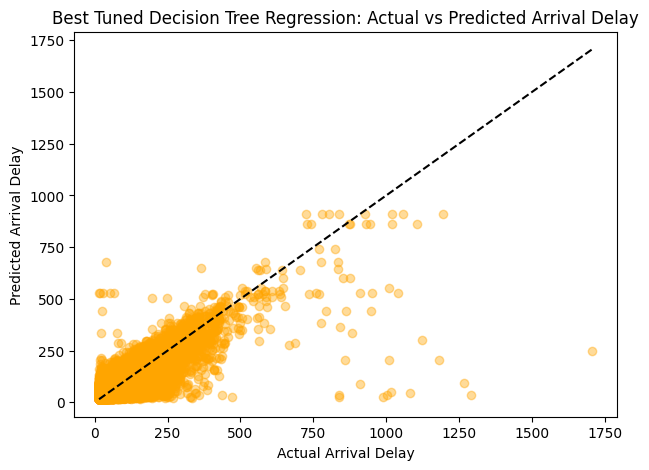

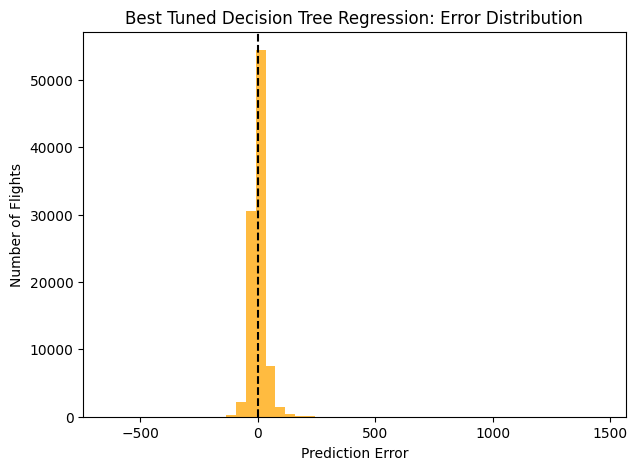

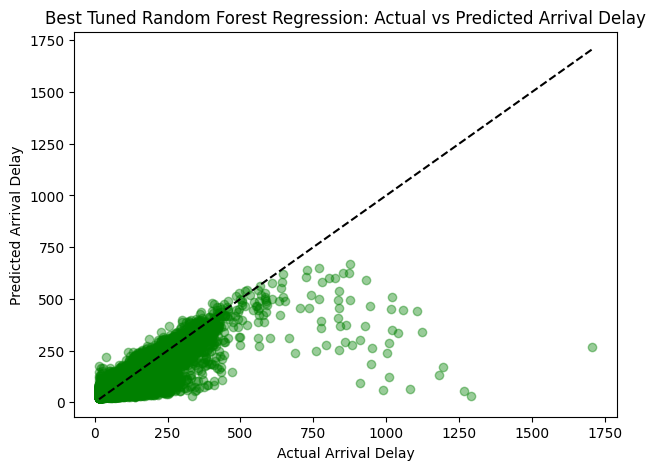

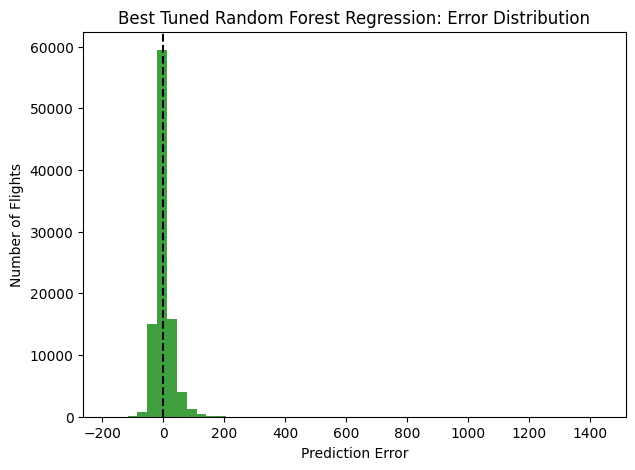

In [175]:
plot_regression_errors(
    model_name="Linear Regression",
    y_test=y_test_reg,
    y_pred=y_pred_linear_best,
    color="skyblue"
)

plot_regression_errors(
    model_name="Best Tuned Decision Tree Regression",
    y_test=y_test_reg,
    y_pred=y_pred_dt_best,
    color="orange"
)

plot_regression_errors(
    model_name="Best Tuned Random Forest Regression",
    y_test=y_test_reg,
    y_pred=y_pred_rf_best,
    color="green"
)

## Analysis:

Linear Regression came out as the weakest model since it could only pick up simple linear relationships between the features and arrival delays. The test R² value of 0.058 showed that it barely explained any variation in the actual delay times, indicating that flight delays aren't that straightforward.

On the flip side, Decision Tree Regression did way better. Once we tuned it, it hit a test MAE of 19.50 minutes and an R² of 0.692 - major improvements! Still, it showed signs of overfitting, possibly because a lone decision tree can get too specific and start memorizing particular flight patterns from the training set.

The real winner here was the tuned Random Forest Regressor. It nailed the lowest test MAE at 19.02 minutes, had an RMSE of 30.87 minutes, and an R² of 0.715. That's better than the tuned Decision Tree by far. For our project, Random Forest just made the most sense because delay times actually depend on all these complex interactions – departure time, route, airline, and more. Plus, Random Forest does a great job of capturing those intricate patterns by averaging predictions from many trees.

---
# 6) Conclusion:

## Arrival Delay Pattern:
The `ArrDelay` distribution was strongly right-skewed, so most flights had small or moderate delays, while only a few were extremely late. However the bigger problem was that Numerical features had low direct correlation with `ArrDelay`, making the models less accurate since they lacked strong numeric predictors for delay times. In contrast, categorical features like airline, origin, destination, and route showed more variation. This indicates that delay behavior is more influenced by flight groups and interactions between features than by simple numerical connections.

## Model Results:

In classification, the **MLP Neural Network** performed the best with an accuracy of about 86.43% and a ROC-AUC score of 0.926. It did well because it could understand complex feature relationships without just using linear rules. For regression, the tuned **Random Forest Regressor** led the way, boasting a MAE of 19.02 minutes, an RMSE of 30.87 minutes, and an R² of 0.715. This made it great at forecasting actual arrival delays.

## Future Improvements:

A major improvement would be to use a stronger dataset with features more directly related to `ArrDelay`, like weather, airport congestion, aircraft rotation, and previous flight history. We could also test how the model handles outliers in regression analysis – really large arrival delays making predictions harder and boosting the RMSE. Here, we kept those big delays to make our model more realistic and robust. Still, future work could compare results with and without that extreme-delay treatment to see what works best.

In [ ]:
if SAVE_MODELS:

    artifacts = {

        "best_rf_model": best_rf_model,
        "best_dt_model": best_dt_model,
        "best_rf_reg_model": best_rf_reg_model,
        "best_rf_params": best_rf_params,
        "best_dt_params": best_dt_params,
        "mlp_default": mlp_default,
        "best_rf_reg_params": best_rf_reg_params,
    }

    joblib.dump(artifacts, ARTIFACT_PATH)
    print(f"Saved artifacts to {ARTIFACT_PATH}")

Saved artifacts to flight_delay_artifacts.joblib
